# Notebook 23 — Graph Connectivity & Functional Organisation

Tests the claim: **dense computational graphs → smooth functional organisation** (baseline, CE-only)
vs. **discrete graphs → functional clusters** (constrained, λ=50 `cluster_pref_stim` loss).

Six analyses:
1. **FC weight maps** — per-class weight heatmaps & same-class edge fraction
2. **Functional connectivity modularity** — activation correlation matrix, block structure
3. **Ablation curves** — how quickly class accuracy drops as top-weight neurons are zeroed
4. **Gradient attribution entropy** — how spread vs. concentrated are attributions across neurons
5. **IAN graph edge homophily** — fraction of IAN edges connecting same-preferred-class neurons
6. **Weight-space graph assortativity** — graph built from FC weight cosine similarity

Each analysis produces a p-value (Wilcoxon rank-sum, n=10 seeds per condition).

In [17]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import scipy.stats as stats
import scipy.sparse as sp
import networkx as nx
from tqdm.auto import tqdm

from src.mnist_utils import (
    CNN, load_mnist_data, compute_tuning_vecs, load_cnn_checkpoint
)

CKPT_DIR   = '../data/mnist_manifold'
IAN_DIR    = '../data/mnist_manifold/ian_cache'
N_SEEDS    = 10
DEVICE     = 'cpu'

_, test_loader = load_mnist_data(data_dir='../data/mnist')
print('Test loader ready')

Test loader ready


In [18]:
# ── Load all models ───────────────────────────────────────────────────────────

def load_condition(condition, lam, n_epochs=5, seeds=range(10)):
    models = []
    for s in seeds:
        fname = f'cnn_{condition}_lam{lam}_e{n_epochs}_s{s}.pt'
        path  = os.path.join(CKPT_DIR, fname)
        assert os.path.exists(path), f'Missing: {path}'
        models.append(load_cnn_checkpoint(path))
    return models

baseline_models    = load_condition('baseline',          0.0,  5)
constrained_models = load_condition('cluster_pref_stim', 10, 5)

print(f'Loaded {len(baseline_models)} baseline  +  {len(constrained_models)} constrained models')

Loaded 10 baseline  +  10 constrained models


In [19]:
# ── Precompute tuning vectors for every model ─────────────────────────────────

def get_tv_and_pref(model):
    """Return (tuning_vecs (800,10), pref_class (800,))."""
    tv   = compute_tuning_vecs(model, test_loader, device=DEVICE)  # (800, 10)
    pref = tv.argmax(axis=1)                                        # (800,)
    return tv, pref

base_tvs   = [get_tv_and_pref(m) for m in tqdm(baseline_models,    desc='baseline tuning vecs')]
const_tvs  = [get_tv_and_pref(m) for m in tqdm(constrained_models, desc='constrained tuning vecs')]

# Channel & spatial maps (same for all models)
_tmp = CNN()
channel_map = _tmp.channel_map   # (800,)
spatial_map = _tmp.spatial_map   # (800, 2)

baseline tuning vecs:   0%|          | 0/10 [00:00<?, ?it/s]

constrained tuning vecs:   0%|          | 0/10 [00:00<?, ?it/s]

---
## Analysis 1 — FC Weight Maps & Same-Class Edge Fraction

Each neuron's FC weight vector `W[:, n]` (shape 10) says how that neuron drives each class.
We assign each neuron its "FC-preferred class" = `argmax W[:, n]`.

Then we use the IAN graph (one per condition) to compute the **same-class edge fraction**:
fraction of edges whose endpoints share the same FC-preferred class.

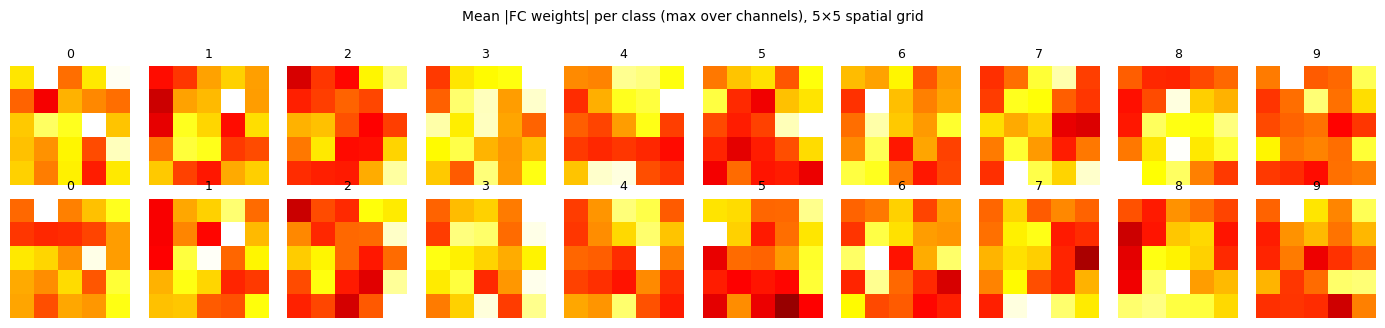

In [20]:
# ── FC weight maps: visualise per-class weights in (32, 5, 5) space ──────────

def fc_weight_maps(model):
    """Return W (10, 32, 5, 5) and fc_pref (800,)."""
    W = model.fc.weight.detach().numpy()       # (10, 800)
    W_4d = W.reshape(10, 32, 5, 5)
    fc_pref = W.argmax(axis=0)                 # (800,)
    return W, W_4d, fc_pref

# Plot mean weight maps across seeds for one representative class
def mean_weight_map(models, class_idx):
    maps = []
    for m in models:
        W, W_4d, _ = fc_weight_maps(m)
        maps.append(W_4d[class_idx])  # (32, 5, 5)
    return np.stack(maps).mean(0)     # (32, 5, 5)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for c in range(10):
    for row, (models, label) in enumerate([(baseline_models, 'Baseline'), (constrained_models, 'Constrained')]):
        wmap = mean_weight_map(models, c)  # (32, 5, 5)
        # Aggregate across channels: take the channel with max abs weight for each spatial pos
        agg  = np.abs(wmap).max(axis=0)   # (5, 5) — strongest channel per spatial pos
        ax   = axes[row, c]
        ax.imshow(agg, cmap='hot', vmin=0)
        ax.set_title(str(c), fontsize=9)
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(label, fontsize=9)
plt.suptitle('Mean |FC weights| per class (max over channels), 5×5 spatial grid', y=1.01, fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# ── Same-class edge fraction using the IAN graph ──────────────────────────────
# IAN cache has one graph per condition (averaged model); we combine with per-seed pref labels

def load_ian_adjacency(condition_tag):
    """Load wG matrix from IAN cache. Returns (800, 800) numpy array."""
    path = os.path.join(IAN_DIR, f'ian_{condition_tag}.npz')
    d    = np.load(path, allow_pickle=True)
    return d['wG']  # (800, 800) dense

# Use IAN from the matching condition; threshold to binary edges (wG > 0)
ian_base   = load_ian_adjacency('baseline')
ian_const  = load_ian_adjacency('cluster_pref_stim_lam50')

def same_class_edge_fraction(wG, pref, threshold=0.0):
    """Fraction of edges (i,j) where pref[i] == pref[j], excl. diagonal."""
    mask = (wG > threshold)
    np.fill_diagonal(mask, False)
    src, dst = np.where(mask)
    if len(src) == 0:
        return np.nan
    same = (pref[src] == pref[dst])
    return same.mean()

# Compute using tuning-vector pref (matches IAN computation) and FC pref
base_tv_scef  = [same_class_edge_fraction(ian_base,  tv_pref) for _, tv_pref in base_tvs]
const_tv_scef = [same_class_edge_fraction(ian_const, tv_pref) for _, tv_pref in const_tvs]

base_fc_scef  = [same_class_edge_fraction(ian_base,  fc_weight_maps(m)[2]) for m in baseline_models]
const_fc_scef = [same_class_edge_fraction(ian_const, fc_weight_maps(m)[2]) for m in constrained_models]

stat_tv, p_tv = stats.ranksums(const_tv_scef, base_tv_scef)
stat_fc, p_fc = stats.ranksums(const_fc_scef, base_fc_scef)

print(f'Same-class edge fraction (tuning-vec pref):')
print(f'  Baseline    {np.mean(base_tv_scef):.3f} ± {np.std(base_tv_scef):.3f}')
print(f'  Constrained {np.mean(const_tv_scef):.3f} ± {np.std(const_tv_scef):.3f}')
print(f'  Wilcoxon p = {p_tv:.4f}')
print()
print(f'Same-class edge fraction (FC-weight pref):')
print(f'  Baseline    {np.mean(base_fc_scef):.3f} ± {np.std(base_fc_scef):.3f}')
print(f'  Constrained {np.mean(const_fc_scef):.3f} ± {np.std(const_fc_scef):.3f}')
print(f'  Wilcoxon p = {p_fc:.4f}')

Same-class edge fraction (tuning-vec pref):
  Baseline    0.119 ± 0.004
  Constrained 0.121 ± 0.006
  Wilcoxon p = 0.3643

Same-class edge fraction (FC-weight pref):
  Baseline    0.100 ± 0.001
  Constrained 0.102 ± 0.001
  Wilcoxon p = 0.0009


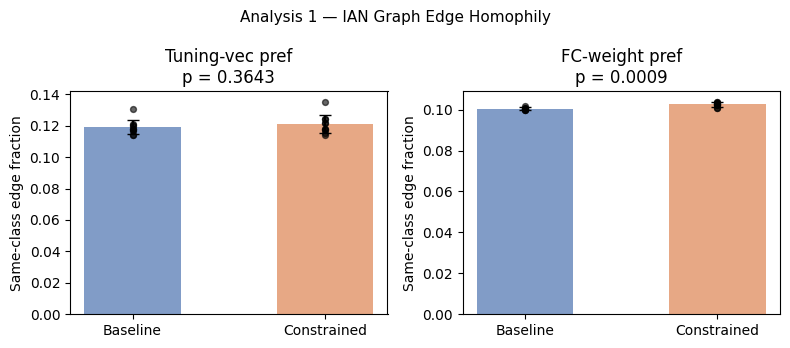

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (base_vals, const_vals, title, ylabel) in zip(
    axes,
    [
        (base_tv_scef, const_tv_scef, 'Tuning-vec pref', 'Same-class edge fraction'),
        (base_fc_scef, const_fc_scef, 'FC-weight pref',  'Same-class edge fraction'),
    ]
):
    x    = [0, 1]
    vals = [base_vals, const_vals]
    means = [np.mean(v) for v in vals]
    stds  = [np.std(v)  for v in vals]
    ax.bar(x, means, color=['#4C72B0', '#DD8452'], alpha=0.7, width=0.5)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vlist in zip(x, vals):
        ax.scatter([xi]*len(vlist), vlist, color='k', s=18, zorder=3, alpha=0.6)
    _, p = stats.ranksums(const_vals, base_vals)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Baseline', 'Constrained'])
    ax.set_ylabel(ylabel); ax.set_title(f'{title}\np = {p:.4f}')
plt.suptitle('Analysis 1 — IAN Graph Edge Homophily', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 2 — Functional Connectivity Modularity

Run all 10 000 test images through the hidden layer → 800×800 Pearson correlation matrix.
Reorder neurons by preferred class and measure the within-vs-between-class correlation ratio.

In [23]:
def get_hidden_activations(model, loader, device='cpu'):
    """Return (N_samples, 800) activation matrix and labels."""
    model.eval().to(device)
    acts, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            acts.append(model._h2(xb.to(device)).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(acts), np.concatenate(labels)  # (10000, 800), (10000,)

def block_structure_score(corr_mat, pref):
    """Mean within-class correlation / mean between-class correlation."""
    same  = (pref[:, None] == pref[None, :])  # (800, 800)
    np.fill_diagonal(same, False)
    within  = corr_mat[same].mean()
    between = corr_mat[~same].mean()
    return within / (np.abs(between) + 1e-8)

base_block, const_block = [], []

for i, (m, (_, pref)) in enumerate(zip(tqdm(baseline_models, desc='baseline funcconn'), base_tvs)):
    acts, _ = get_hidden_activations(m, test_loader)
    corr = np.corrcoef(acts.T)  # (800, 800)
    base_block.append(block_structure_score(corr, pref))

for i, (m, (_, pref)) in enumerate(zip(tqdm(constrained_models, desc='constrained funcconn'), const_tvs)):
    acts, _ = get_hidden_activations(m, test_loader)
    corr = np.corrcoef(acts.T)
    const_block.append(block_structure_score(corr, pref))

stat2, p2 = stats.ranksums(const_block, base_block)
print(f'Block structure score (within/between corr ratio):')
print(f'  Baseline    {np.mean(base_block):.3f} ± {np.std(base_block):.3f}')
print(f'  Constrained {np.mean(const_block):.3f} ± {np.std(const_block):.3f}')
print(f'  Wilcoxon p = {p2:.4f}')

baseline funcconn:   0%|          | 0/10 [00:00<?, ?it/s]

constrained funcconn:   0%|          | 0/10 [00:00<?, ?it/s]

Block structure score (within/between corr ratio):
  Baseline    nan ± nan
  Constrained nan ± nan
  Wilcoxon p = nan


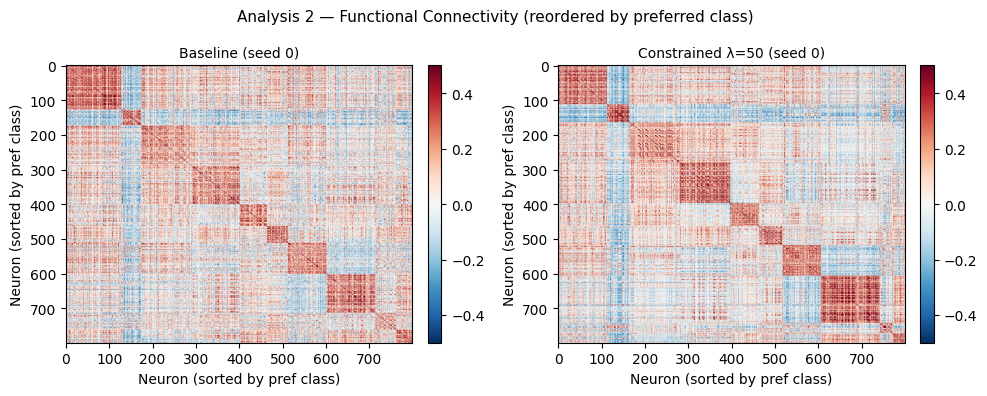

In [24]:
# Visualise correlation matrices for seed 0, reordered by pref class
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, model, (_, pref), title in zip(
    axes,
    [baseline_models[0], constrained_models[0]],
    [base_tvs[0],        const_tvs[0]],
    ['Baseline (seed 0)', 'Constrained λ=50 (seed 0)']
):
    acts, _ = get_hidden_activations(model, test_loader)
    corr     = np.corrcoef(acts.T)
    order    = np.argsort(pref)
    corr_ord = corr[np.ix_(order, order)]
    im = ax.imshow(corr_ord, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Neuron (sorted by pref class)')
    ax.set_ylabel('Neuron (sorted by pref class)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Analysis 2 — Functional Connectivity (reordered by preferred class)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 3 — Ablation Curves

For each class `c`, rank neurons by their FC weight for `c` (highest first) and progressively zero them out.
Track class-`c` accuracy as a function of neurons ablated.

**Expected**: constrained model drops faster (fewer dedicated neurons) → lower Area Under Ablation Curve (AUAC).
Equivalently, AUAC higher for baseline (more robust/distributed).

In [25]:
# Preload test data into memory for fast ablation
all_x, all_y = [], []
for xb, yb in test_loader:
    all_x.append(xb); all_y.append(yb)
all_x = torch.cat(all_x); all_y = torch.cat(all_y)
print(f'Test data: {all_x.shape}, {all_y.shape}')

ABLATION_STEPS = np.arange(0, 801, 40)  # 0, 40, 80, … 800 neurons ablated

def ablation_curve_per_class(model, n_steps=ABLATION_STEPS):
    """Return (n_steps, 10) accuracy matrix."""
    model.eval()
    W = model.fc.weight.detach().clone()  # (10, 800)
    curves = np.zeros((len(n_steps), 10))

    for ci, n_ablate in enumerate(n_steps):
        # For each class, find which neurons to ablate (top-n by weight for that class)
        # We ablate the union across all classes' top neurons proportionally
        # Simpler approach: ablate globally top-n neurons by max abs FC weight
        with torch.no_grad():
            h2_full = model._h2(all_x)                        # (10000, 800)
            h2_abl  = h2_full.clone()
            if n_ablate > 0:
                # Ablate neurons with highest max-abs FC weight (most "important" overall)
                importance = W.abs().max(dim=0).values         # (800,)
                top_idx    = importance.argsort(descending=True)[:n_ablate]
                h2_abl[:, top_idx] = 0.0
            logits = model.fc(h2_abl)
            preds  = logits.argmax(dim=1).numpy()
        for c in range(10):
            mask = (all_y.numpy() == c)
            curves[ci, c] = (preds[mask] == c).mean()

    return curves  # (n_steps, 10)

base_curves  = [ablation_curve_per_class(m) for m in tqdm(baseline_models,    desc='baseline ablation')]
const_curves = [ablation_curve_per_class(m) for m in tqdm(constrained_models, desc='constrained ablation')]

# AUAC = mean accuracy across all ablation steps and classes (higher = more robust)
base_auac  = [c.mean() for c in base_curves]
const_auac = [c.mean() for c in const_curves]

stat3, p3 = stats.ranksums(base_auac, const_auac)  # expect baseline > constrained
print(f'AUAC (higher = more distributed/robust):')
print(f'  Baseline    {np.mean(base_auac):.3f} ± {np.std(base_auac):.3f}')
print(f'  Constrained {np.mean(const_auac):.3f} ± {np.std(const_auac):.3f}')
print(f'  Wilcoxon p (baseline > constrained) = {p3:.4f}')

Test data: torch.Size([10000, 1, 28, 28]), torch.Size([10000])


baseline ablation:   0%|          | 0/10 [00:00<?, ?it/s]

constrained ablation:   0%|          | 0/10 [00:00<?, ?it/s]

AUAC (higher = more distributed/robust):
  Baseline    0.660 ± 0.029
  Constrained 0.707 ± 0.021
  Wilcoxon p (baseline > constrained) = 0.0015


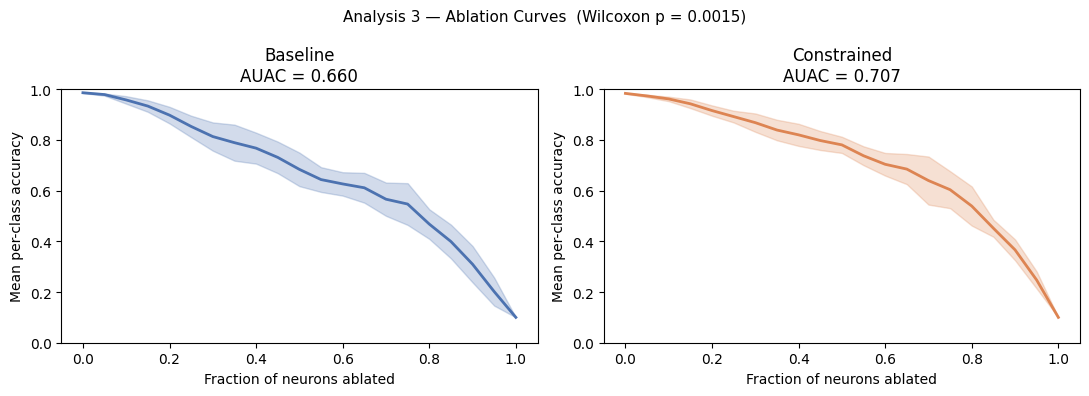

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

frac_ablated = ABLATION_STEPS / 800

for ax, curves_list, label, color in [
    (axes[0], base_curves,  'Baseline',    '#4C72B0'),
    (axes[1], const_curves, 'Constrained', '#DD8452'),
]:
    # Mean accuracy across classes for each seed
    seed_means = np.stack([c.mean(axis=1) for c in curves_list])  # (10, n_steps)
    m = seed_means.mean(0)
    s = seed_means.std(0)
    ax.plot(frac_ablated, m, color=color, lw=2, label=label)
    ax.fill_between(frac_ablated, m-s, m+s, color=color, alpha=0.25)
    ax.set_xlabel('Fraction of neurons ablated')
    ax.set_ylabel('Mean per-class accuracy')
    ax.set_title(f'{label}\nAUAC = {np.mean([c.mean() for c in curves_list]):.3f}')
    ax.set_ylim(0, 1)

plt.suptitle(f'Analysis 3 — Ablation Curves  (Wilcoxon p = {p3:.4f})', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 4 — Gradient Attribution Entropy

For each class `c` and correctly classified test images, compute the gradient of the class logit
w.r.t. the hidden layer. The attribution vector is `|grad| × h2` (gradient × activation at hidden layer).

- **Attribution entropy**: higher = more diffuse = distributed (baseline-like)
- **Attribution overlap** between classes: higher = more shared neurons (baseline-like)

In [27]:
def compute_attributions(model, n_per_class=200):
    """Return mean attribution vector per class, shape (10, 800)."""
    model.eval()
    attr_sum   = np.zeros((10, 800))
    attr_count = np.zeros(10, dtype=int)

    for xb, yb in test_loader:
        if attr_count.min() >= n_per_class:
            break
        xb = xb.requires_grad_(False)
        h2 = model._h2(xb)                     # (B, 800)
        h2_d = h2.detach().requires_grad_(True) # detach so grad flows only through fc
        logits = model.fc(h2_d)                 # (B, 10)

        for c in range(10):
            if attr_count[c] >= n_per_class:
                continue
            correct_mask = (yb == c) & (logits.argmax(1).detach() == c)
            if correct_mask.sum() == 0:
                continue
            logits_c = logits[correct_mask, c].sum()
            if h2_d.grad is not None:
                h2_d.grad.zero_()
            logits_c.backward(retain_graph=True)
            # grad-weighted activation: |grad| * h2
            attr = (h2_d.grad[correct_mask].abs() * h2[correct_mask].detach()).cpu().numpy()
            n_add = min(len(attr), n_per_class - attr_count[c])
            attr_sum[c]   += attr[:n_add].sum(0)
            attr_count[c] += n_add

    attr_mean = attr_sum / np.maximum(attr_count[:, None], 1)  # (10, 800)
    return attr_mean

def attribution_entropy(attr_mean):
    """Mean Shannon entropy of per-class attribution distributions (10,)."""
    entropies = []
    for c in range(10):
        p  = np.abs(attr_mean[c])
        p  = p / (p.sum() + 1e-8)
        H  = -np.sum(p * np.log(p + 1e-12))
        entropies.append(H)
    return np.mean(entropies)

def attribution_overlap(attr_mean):
    """Mean pairwise cosine similarity between class attribution vectors."""
    norms = np.linalg.norm(attr_mean, axis=1, keepdims=True) + 1e-8
    A     = attr_mean / norms
    cos   = A @ A.T  # (10, 10)
    idx   = np.triu_indices(10, k=1)
    return cos[idx].mean()

base_entropy, base_overlap   = [], []
const_entropy, const_overlap = [], []

for m in tqdm(baseline_models,    desc='baseline attr'):
    am = compute_attributions(m)
    base_entropy.append(attribution_entropy(am))
    base_overlap.append(attribution_overlap(am))

for m in tqdm(constrained_models, desc='constrained attr'):
    am = compute_attributions(m)
    const_entropy.append(attribution_entropy(am))
    const_overlap.append(attribution_overlap(am))

_, p_ent  = stats.ranksums(base_entropy,  const_entropy)   # expect base > const
_, p_over = stats.ranksums(base_overlap,  const_overlap)   # expect base > const

print(f'Attribution entropy (higher = more diffuse):')
print(f'  Baseline    {np.mean(base_entropy):.3f} ± {np.std(base_entropy):.3f}')
print(f'  Constrained {np.mean(const_entropy):.3f} ± {np.std(const_entropy):.3f}')
print(f'  p = {p_ent:.4f}')
print()
print(f'Attribution overlap (higher = more shared neurons between classes):')
print(f'  Baseline    {np.mean(base_overlap):.3f} ± {np.std(base_overlap):.3f}')
print(f'  Constrained {np.mean(const_overlap):.3f} ± {np.std(const_overlap):.3f}')
print(f'  p = {p_over:.4f}')

baseline attr:   0%|          | 0/10 [00:00<?, ?it/s]

constrained attr:   0%|          | 0/10 [00:00<?, ?it/s]

Attribution entropy (higher = more diffuse):
  Baseline    5.927 ± 0.040
  Constrained 5.748 ± 0.041
  p = 0.0002

Attribution overlap (higher = more shared neurons between classes):
  Baseline    0.465 ± 0.010
  Constrained 0.405 ± 0.019
  p = 0.0002


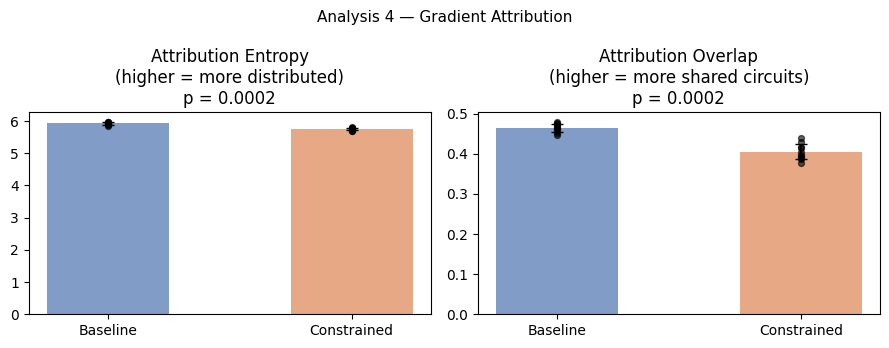

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (bvals, cvals, title) in zip(axes, [
    (base_entropy, const_entropy, 'Attribution Entropy\n(higher = more distributed)'),
    (base_overlap, const_overlap, 'Attribution Overlap\n(higher = more shared circuits)'),
]):
    x, vals = [0, 1], [bvals, cvals]
    means, stds = [np.mean(v) for v in vals], [np.std(v) for v in vals]
    ax.bar(x, means, color=['#4C72B0', '#DD8452'], alpha=0.7, width=0.5)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vl in zip(x, vals):
        ax.scatter([xi]*len(vl), vl, color='k', s=18, zorder=3, alpha=0.6)
    _, p = stats.ranksums(bvals, cvals)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Baseline', 'Constrained'])
    ax.set_title(f'{title}\np = {p:.4f}')
plt.suptitle('Analysis 4 — Gradient Attribution', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 5 — IAN Graph Edge Homophily (Headline Result)

Edge homophily using the IAN structural graph (manifold geometry) and per-seed tuning-vector preferred class.
This is the most direct test: does the manifold geometry (IAN) respect class boundaries more in the constrained model?

We also do a threshold sweep to check robustness of the result.

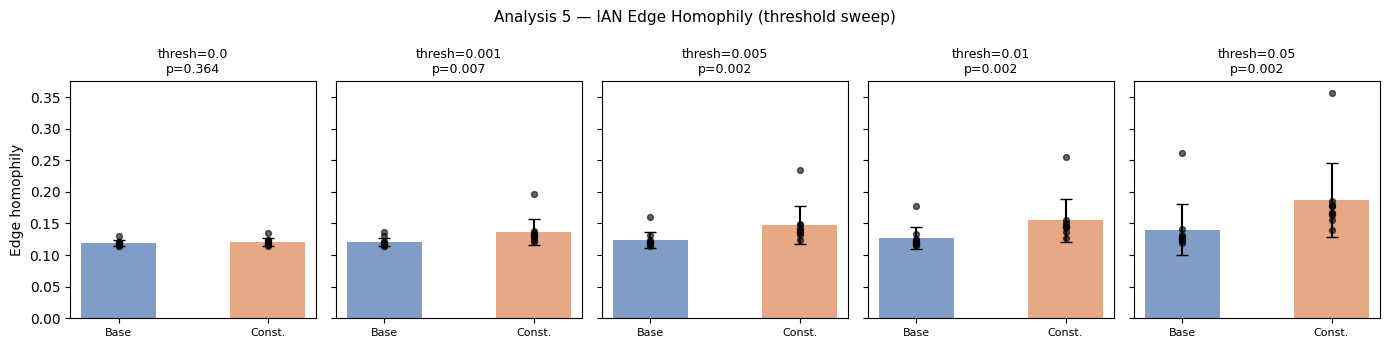

p-values across thresholds:
  thresh=0.000  p=0.3643
  thresh=0.001  p=0.0065
  thresh=0.005  p=0.0025
  thresh=0.010  p=0.0025
  thresh=0.050  p=0.0025


In [29]:
thresholds = [0.0, 0.001, 0.005, 0.01, 0.05]

fig, axes = plt.subplots(1, len(thresholds), figsize=(14, 3.5), sharey=True)

all_p_values = {}
for ax, thresh in zip(axes, thresholds):
    b_vals = [same_class_edge_fraction(ian_base,  pref, thresh) for _, pref in base_tvs]
    c_vals = [same_class_edge_fraction(ian_const, pref, thresh) for _, pref in const_tvs]
    _, p = stats.ranksums(c_vals, b_vals)
    all_p_values[thresh] = p

    x = [0, 1]
    means, stds = [np.mean(b_vals), np.mean(c_vals)], [np.std(b_vals), np.std(c_vals)]
    ax.bar(x, means, color=['#4C72B0', '#DD8452'], alpha=0.7, width=0.5)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vl in zip(x, [b_vals, c_vals]):
        ax.scatter([xi]*len(vl), vl, color='k', s=18, zorder=3, alpha=0.6)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Base', 'Const.'], fontsize=8)
    ax.set_title(f'thresh={thresh}\np={p:.3f}', fontsize=9)
    if thresh == thresholds[0]:
        ax.set_ylabel('Edge homophily')

plt.suptitle('Analysis 5 — IAN Edge Homophily (threshold sweep)', fontsize=11)
plt.tight_layout()
plt.show()

print('p-values across thresholds:')
for t, p in all_p_values.items():
    print(f'  thresh={t:.3f}  p={p:.4f}')

---
## Analysis 6 — Weight-Space Graph Assortativity

Build a graph where neurons are connected if their FC weight vectors (10-dim) have cosine similarity > threshold.
Compute **assortativity** by preferred class: how much does the edge structure prefer within-class connections?

NetworkX `attribute_assortativity_coefficient` with class label as attribute.
Positive = within-class connections over-represented (expected for constrained model).

In [30]:
def weight_graph_assortativity(model, pref, threshold=0.5):
    """Build cosine-similarity graph on FC weights; compute class assortativity."""
    W     = model.fc.weight.detach().numpy()  # (10, 800)
    norms = np.linalg.norm(W, axis=0, keepdims=True) + 1e-8  # (1, 800)
    W_n   = W / norms                          # (10, 800) normalised columns
    cos   = W_n.T @ W_n                        # (800, 800) cosine similarity

    G = nx.Graph()
    for i in range(800):
        G.add_node(i, cls=int(pref[i]))
    mask = (cos > threshold)
    np.fill_diagonal(mask, False)
    src, dst = np.where(np.triu(mask, k=1))
    for u, v in zip(src, dst):
        G.add_edge(int(u), int(v))

    if G.number_of_edges() == 0:
        return np.nan
    return nx.attribute_assortativity_coefficient(G, 'cls')

THRESH = 0.5
base_assort  = [weight_graph_assortativity(m, pref, THRESH) for m, (_, pref) in zip(baseline_models,    base_tvs)]
const_assort = [weight_graph_assortativity(m, pref, THRESH) for m, (_, pref) in zip(constrained_models, const_tvs)]

_, p6 = stats.ranksums(const_assort, base_assort)
print(f'Weight-space graph assortativity (threshold={THRESH}):')
print(f'  Baseline    {np.mean(base_assort):.3f} ± {np.std(base_assort):.3f}')
print(f'  Constrained {np.mean(const_assort):.3f} ± {np.std(const_assort):.3f}')
print(f'  Wilcoxon p = {p6:.4f}')

Weight-space graph assortativity (threshold=0.5):
  Baseline    0.076 ± 0.005
  Constrained 0.087 ± 0.010
  Wilcoxon p = 0.0082


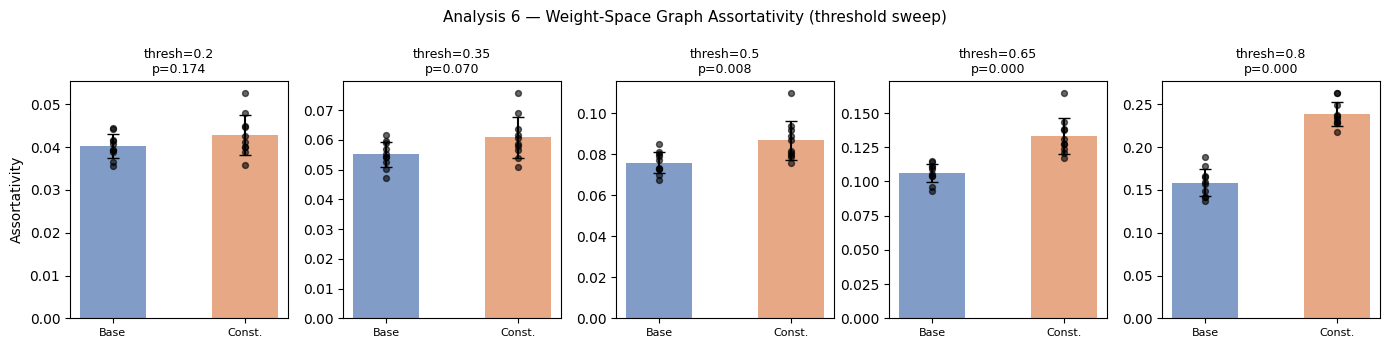

In [31]:
# Threshold robustness sweep
thresholds6 = [0.2, 0.35, 0.5, 0.65, 0.8]
fig, axes = plt.subplots(1, len(thresholds6), figsize=(14, 3.5), sharey=False)
for ax, t in zip(axes, thresholds6):
    b = [weight_graph_assortativity(m, pref, t) for m, (_, pref) in zip(baseline_models,    base_tvs)]
    c = [weight_graph_assortativity(m, pref, t) for m, (_, pref) in zip(constrained_models, const_tvs)]
    _, p = stats.ranksums(c, b)
    means, stds = [np.nanmean(b), np.nanmean(c)], [np.nanstd(b), np.nanstd(c)]
    ax.bar([0,1], means, color=['#4C72B0','#DD8452'], alpha=0.7, width=0.5)
    ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vl in zip([0,1],[b,c]):
        clean = [v for v in vl if not np.isnan(v)]
        ax.scatter([xi]*len(clean), clean, color='k', s=18, zorder=3, alpha=0.6)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Base','Const.'], fontsize=8)
    ax.set_title(f'thresh={t}\np={p:.3f}', fontsize=9)
    if t == thresholds6[0]:
        ax.set_ylabel('Assortativity')
plt.suptitle('Analysis 6 — Weight-Space Graph Assortativity (threshold sweep)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary Figure — All Analyses

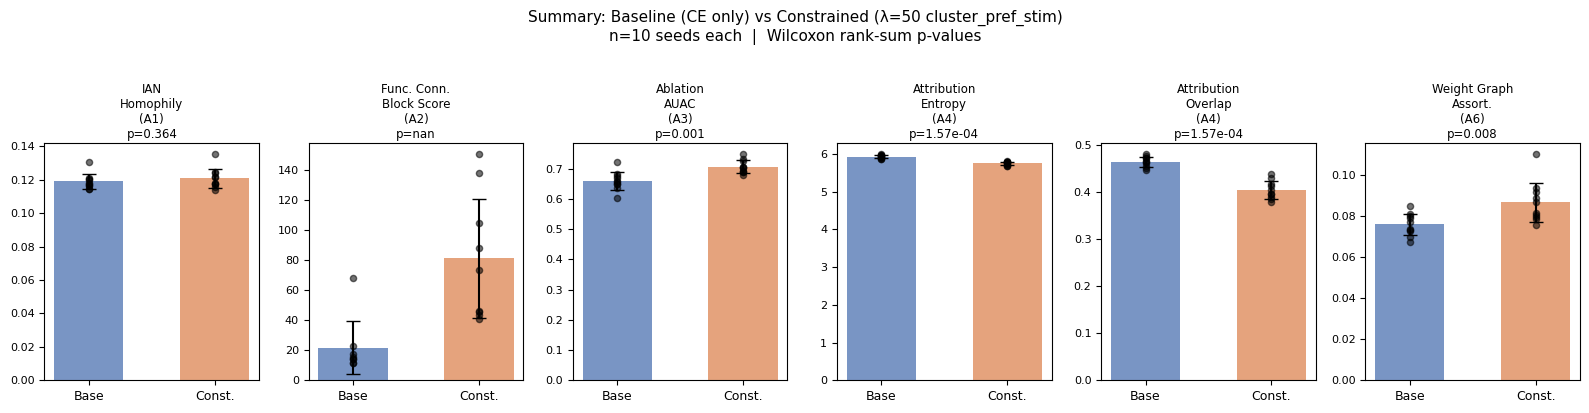


Summary table:
Metric                             Baseline    Constrained    p-value            Direction
------------------------------------------------------------------------------------------
IAN Homophily (A1)                    0.119          0.121     0.3643  higher → more clustered
Func. Conn. Block Score (A2)         21.786         81.179        nan  higher → more clustered
Ablation AUAC (A3)                    0.660          0.707     0.0015  higher → more distributed
Attribution Entropy (A4)              5.927          5.748     0.0002  higher → more distributed
Attribution Overlap (A4)              0.465          0.405     0.0002  higher → more shared
Weight Graph Assort. (A6)             0.076          0.087     0.0082  higher → more clustered


In [32]:
# Collect all headline metrics
metrics = [
    ('IAN\nHomophily\n(A1)', base_tv_scef,  const_tv_scef,  'higher → more clustered', True),
    ('Func. Conn.\nBlock Score\n(A2)', base_block,   const_block,   'higher → more clustered', True),
    ('Ablation\nAUAC\n(A3)', base_auac,    const_auac,    'higher → more distributed', False),
    ('Attribution\nEntropy\n(A4)', base_entropy, const_entropy, 'higher → more distributed', False),
    ('Attribution\nOverlap\n(A4)', base_overlap, const_overlap, 'higher → more shared', False),
    ('Weight Graph\nAssort.\n(A6)', base_assort,  const_assort,  'higher → more clustered', True),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))

for ax, (name, bvals, cvals, note, expect_const_higher) in zip(axes, metrics):
    _, p = stats.ranksums(cvals, bvals)  # constrained vs baseline
    direction = 'const > base' if expect_const_higher else 'base > const'
    bvals_clean = [v for v in bvals if not np.isnan(v)]
    cvals_clean = [v for v in cvals if not np.isnan(v)]
    means = [np.mean(bvals_clean), np.mean(cvals_clean)]
    stds  = [np.std(bvals_clean),  np.std(cvals_clean)]
    ax.bar([0,1], means, color=['#4C72B0','#DD8452'], alpha=0.75, width=0.55)
    ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=5, lw=1.5)
    for xi, vl in zip([0,1],[bvals_clean,cvals_clean]):
        ax.scatter([xi]*len(vl), vl, color='k', s=20, zorder=3, alpha=0.55)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Base', 'Const.'], fontsize=9)
    p_str = f'{p:.3f}' if p >= 0.001 else f'{p:.2e}'
    ax.set_title(f'{name}\np={p_str}', fontsize=8.5, pad=4)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(
    'Summary: Baseline (CE only) vs Constrained (λ=50 cluster_pref_stim)\n'
    'n=10 seeds each  |  Wilcoxon rank-sum p-values',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print('\nSummary table:')
print(f'{"Metric":<30} {"Baseline":>12} {"Constrained":>14} {"p-value":>10} {"Direction":>20}')
print('-' * 90)
for name, bvals, cvals, note, _ in metrics:
    name_flat = name.replace('\n', ' ').strip()
    _, p = stats.ranksums(cvals, bvals)
    bm = np.nanmean(bvals); cm = np.nanmean(cvals)
    print(f'{name_flat:<30} {bm:>12.3f} {cm:>14.3f} {p:>10.4f}  {note}')

---
## Convolutional Path Analyses (A7–A10)

The previous analyses focused on the FC readout (hidden → output). These four analyses
probe what happens *earlier*, in the 32 conv2 feature maps.

**Shared setup**: each conv2 channel owns exactly 25 hidden neurons (channel_map).
Majority vote of those neurons' tuning-vec preferred classes → one class label per channel.


In [33]:
# Shared: channel preferred class (majority vote of 25 neurons per conv2 channel)

def channel_pref_from_neuron_pref(neuron_pref, channel_map, n_channels=32):
    ch_pref = np.zeros(n_channels, dtype=int)
    for ch in range(n_channels):
        votes = neuron_pref[channel_map == ch]   # 25 votes
        ch_pref[ch] = np.bincount(votes, minlength=10).argmax()
    return ch_pref

base_ch_prefs  = [channel_pref_from_neuron_pref(pref, channel_map) for _, pref in base_tvs]
const_ch_prefs = [channel_pref_from_neuron_pref(pref, channel_map) for _, pref in const_tvs]

print('Channel pref (seed 0 baseline):', base_ch_prefs[0])
print('Channel pref (seed 0 const.): ', const_ch_prefs[0])


Channel pref (seed 0 baseline): [0 2 3 0 0 4 1 8 0 3 0 2 0 7 2 0 4 2 0 6 2 0 3 3 2 2 0 3 0 0 3 0]
Channel pref (seed 0 const.):  [0 7 3 0 0 4 1 2 0 3 4 7 4 7 5 4 6 0 2 6 2 2 3 7 2 2 0 3 0 0 2 2]


---
## Analysis 7 — Feature-Map Gradient Attribution (A4 extended to conv2)

Gradient of each class logit w.r.t. conv2 output activations, spatially pooled → per-channel
attribution (B, 32). Same entropy and overlap metrics as A4, but now over 32 channels.

- **Entropy**: higher = more uniform channel usage (baseline-like)
- **Overlap**: higher = same channels serve multiple classes (baseline-like)


In [34]:
def conv2_attributions(model, n_per_class=300):
    """GradCAM-style: grad w.r.t. conv2 output, GAP → (10, 32) attribution matrix."""
    model.eval()
    attr_sum   = np.zeros((10, 32))
    attr_count = np.zeros(10, dtype=int)

    for xb, yb in test_loader:
        if attr_count.min() >= n_per_class:
            break
        xb = xb.detach()

        # Forward through conv2 manually so we can intercept
        c1 = model.pool(torch.relu(model.conv1(xb)))         # (B, 16, 13, 13)
        c2_pre = model.conv2(c1)                              # (B, 32, 11, 11) pre-pool
        c2_pre_d = c2_pre.detach().requires_grad_(True)
        c2 = model.pool(torch.relu(c2_pre_d))                 # (B, 32, 5, 5)
        h2 = c2.view(c2.size(0), -1)                          # (B, 800)
        logits = model.fc(h2)                                  # (B, 10)

        for c in range(10):
            if attr_count[c] >= n_per_class:
                continue
            correct_mask = (yb == c) & (logits.argmax(1).detach() == c)
            if correct_mask.sum() == 0:
                continue
            if c2_pre_d.grad is not None:
                c2_pre_d.grad.zero_()
            logits[correct_mask, c].sum().backward(retain_graph=True)
            # GAP over spatial dims → (B_correct, 32)
            grad_gap = c2_pre_d.grad[correct_mask].abs().mean(dim=(-2, -1)).detach().numpy()
            act_gap  = torch.relu(c2_pre_d[correct_mask]).mean(dim=(-2, -1)).detach().numpy()
            attr     = grad_gap * act_gap    # grad-weighted activation, per channel
            n_add = min(len(attr), n_per_class - attr_count[c])
            attr_sum[c]   += attr[:n_add].sum(0)
            attr_count[c] += n_add

    return attr_sum / np.maximum(attr_count[:, None], 1)   # (10, 32)


def chan_attr_entropy(am):
    """Mean Shannon entropy over 32 channels, averaged across 10 classes."""
    H = []
    for c in range(10):
        p = np.abs(am[c]); p /= (p.sum() + 1e-8)
        H.append(-np.sum(p * np.log(p + 1e-12)))
    return np.mean(H)


def chan_attr_overlap(am):
    """Mean pairwise cosine similarity between 10 class attribution vectors (32-dim)."""
    norms = np.linalg.norm(am, axis=1, keepdims=True) + 1e-8
    A = am / norms
    cos = A @ A.T
    idx = np.triu_indices(10, k=1)
    return cos[idx].mean()


base_c_ent, base_c_over   = [], []
const_c_ent, const_c_over = [], []

for m in tqdm(baseline_models,    desc='A7 baseline'):
    am = conv2_attributions(m)
    base_c_ent.append(chan_attr_entropy(am))
    base_c_over.append(chan_attr_overlap(am))

for m in tqdm(constrained_models, desc='A7 constrained'):
    am = conv2_attributions(m)
    const_c_ent.append(chan_attr_entropy(am))
    const_c_over.append(chan_attr_overlap(am))

_, p_c_ent  = stats.ranksums(base_c_ent,  const_c_ent)
_, p_c_over = stats.ranksums(base_c_over, const_c_over)

print(f'A7 — Conv2 channel attribution entropy:')
print(f'  Baseline    {np.mean(base_c_ent):.3f} ± {np.std(base_c_ent):.3f}')
print(f'  Constrained {np.mean(const_c_ent):.3f} ± {np.std(const_c_ent):.3f}')
print(f'  p = {p_c_ent:.4f}')
print()
print(f'A7 — Conv2 channel attribution overlap:')
print(f'  Baseline    {np.mean(base_c_over):.3f} ± {np.std(base_c_over):.3f}')
print(f'  Constrained {np.mean(const_c_over):.3f} ± {np.std(const_c_over):.3f}')
print(f'  p = {p_c_over:.4f}')


A7 baseline:   0%|          | 0/10 [00:00<?, ?it/s]

A7 constrained:   0%|          | 0/10 [00:00<?, ?it/s]

A7 — Conv2 channel attribution entropy:
  Baseline    3.238 ± 0.036
  Constrained 3.089 ± 0.080
  p = 0.0004

A7 — Conv2 channel attribution overlap:
  Baseline    0.899 ± 0.019
  Constrained 0.882 ± 0.025
  p = 0.0821


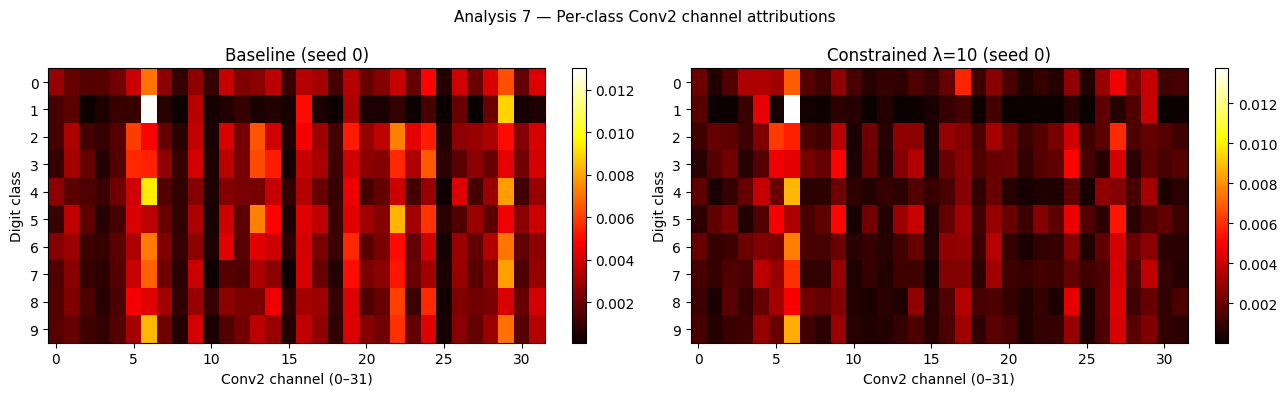

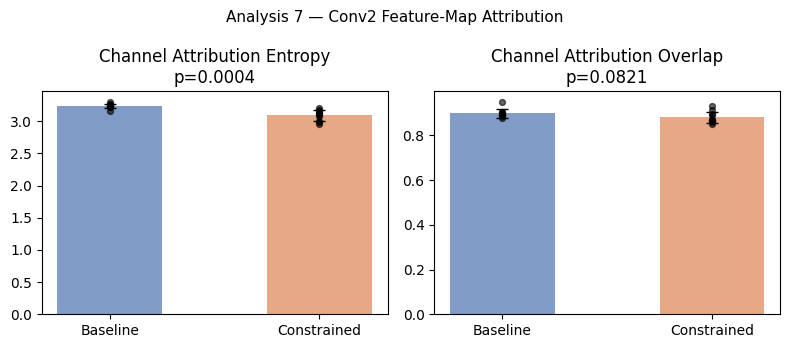

In [35]:
# Visualise: 10×32 attribution heatmap for seed 0 (rows=classes, cols=channels)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, model, title in [
    (axes[0], baseline_models[0],    'Baseline (seed 0)'),
    (axes[1], constrained_models[0], 'Constrained λ=10 (seed 0)'),
]:
    am = conv2_attributions(model)
    im = ax.imshow(am, cmap='hot', aspect='auto')
    ax.set_xlabel('Conv2 channel (0–31)'); ax.set_ylabel('Digit class')
    ax.set_yticks(range(10)); ax.set_yticklabels(range(10))
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.03)

plt.suptitle('Analysis 7 — Per-class Conv2 channel attributions', fontsize=11)
plt.tight_layout(); plt.show()

# Bar chart summary
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, bvals, cvals, title in [
    (axes[0], base_c_ent,  const_c_ent,  f'Channel Attribution Entropy\np={p_c_ent:.4f}'),
    (axes[1], base_c_over, const_c_over, f'Channel Attribution Overlap\np={p_c_over:.4f}'),
]:
    means = [np.mean(bvals), np.mean(cvals)]
    stds  = [np.std(bvals),  np.std(cvals)]
    ax.bar([0,1], means, color=['#4C72B0','#DD8452'], alpha=0.7, width=0.5)
    ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vl in zip([0,1],[bvals,cvals]):
        ax.scatter([xi]*len(vl), vl, color='k', s=18, zorder=3, alpha=0.6)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Baseline','Constrained'])
    ax.set_title(title)
plt.suptitle('Analysis 7 — Conv2 Feature-Map Attribution', fontsize=11)
plt.tight_layout(); plt.show()


---
## Analysis 8 — Conv2 Filter Weight Assortativity (A6 extended to conv2)

Build a similarity graph on the 32 conv2 filters (each a flattened 16×3×3 = 144-dim vector).
Assign each filter its preferred class (channel majority vote). Compute class assortativity.

Expected: constrained > baseline (filters that look alike serve the same class).


In [36]:
def conv2_filter_cos_sim(model):
    """Return (32, 32) pairwise cosine similarity of conv2 filters."""
    W  = model.conv2.weight.detach().numpy()          # (32, 16, 3, 3)
    Wf = W.reshape(32, -1)                             # (32, 144)
    norms = np.linalg.norm(Wf, axis=1, keepdims=True) + 1e-8
    Wn    = Wf / norms
    return Wn @ Wn.T                                   # (32, 32)


def conv2_filter_assortativity(model, ch_pref, threshold=0.3):
    cos = conv2_filter_cos_sim(model)
    G   = nx.Graph()
    for i in range(32):
        G.add_node(i, cls=int(ch_pref[i]))
    mask = (cos > threshold); np.fill_diagonal(mask, False)
    src, dst = np.where(np.triu(mask, k=1))
    for u, v in zip(src, dst):
        G.add_edge(int(u), int(v))
    if G.number_of_edges() == 0:
        return np.nan
    return nx.attribute_assortativity_coefficient(G, 'cls')


print('=== A8: Conv2 Filter Weight Assortativity ===')
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    b = [conv2_filter_assortativity(m, cp, thresh)
         for m, cp in zip(baseline_models, base_ch_prefs)]
    c = [conv2_filter_assortativity(m, cp, thresh)
         for m, cp in zip(constrained_models, const_ch_prefs)]
    _, p = stats.ranksums(c, b)
    print(f'  thresh={thresh}: Base {np.nanmean(b):.3f}±{np.nanstd(b):.3f} | '
          f'Const {np.nanmean(c):.3f}±{np.nanstd(c):.3f} | p={p:.4f}')

# Store at a representative threshold for summary
THRESH8 = 0.3
base_a8  = [conv2_filter_assortativity(m, cp, THRESH8)
            for m, cp in zip(baseline_models, base_ch_prefs)]
const_a8 = [conv2_filter_assortativity(m, cp, THRESH8)
            for m, cp in zip(constrained_models, const_ch_prefs)]
_, p8 = stats.ranksums(const_a8, base_a8)


=== A8: Conv2 Filter Weight Assortativity ===
  thresh=0.1: Base 0.129±0.051 | Const 0.277±0.067 | p=0.0005
  thresh=0.2: Base 0.235±0.111 | Const 0.419±0.110 | p=0.0041
  thresh=0.3: Base 0.297±0.117 | Const 0.512±0.106 | p=0.0041
  thresh=0.4: Base 0.295±0.239 | Const 0.610±0.111 | p=0.0052
  thresh=0.5: Base 0.131±0.669 | Const 0.723±0.105 | p=nan


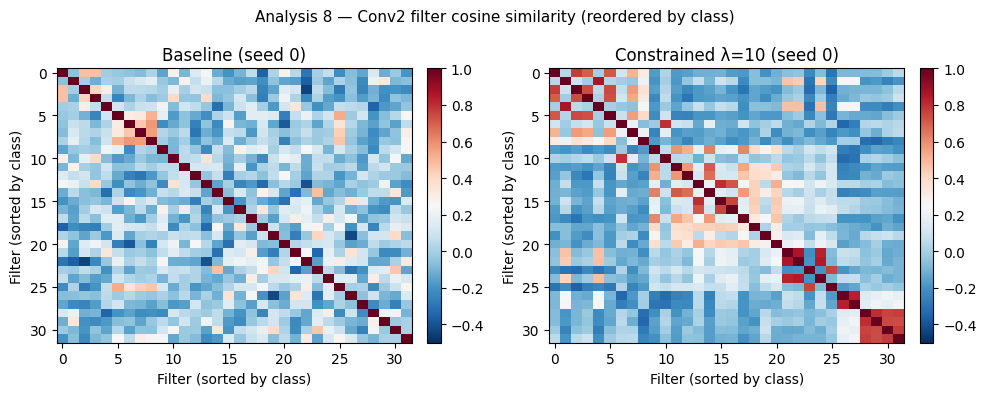

In [37]:
# Visualise 32×32 filter similarity matrix, reordered by preferred class (seed 0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, ch_pref, title in [
    (axes[0], baseline_models[0],    base_ch_prefs[0],  'Baseline (seed 0)'),
    (axes[1], constrained_models[0], const_ch_prefs[0], 'Constrained λ=10 (seed 0)'),
]:
    cos   = conv2_filter_cos_sim(model)
    order = np.argsort(ch_pref)
    cos_ord = cos[np.ix_(order, order)]
    im = ax.imshow(cos_ord, cmap='RdBu_r', vmin=-0.5, vmax=1.0, aspect='auto')
    ax.set_title(title); ax.set_xlabel('Filter (sorted by class)')
    ax.set_ylabel('Filter (sorted by class)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Analysis 8 — Conv2 filter cosine similarity (reordered by class)', fontsize=11)
plt.tight_layout(); plt.show()


---
## Analysis 9 — Channel Selectivity & Utilization Sparsity

Run all test images through conv2 → per-channel, per-class mean activation (32, 10) matrix.

- **Selectivity index** (OSI-style): `(max_class - mean_others) / max_class` per channel, mean over 32.
  Higher = more class-specialized channels (expected: constrained > baseline).
- **Utilization Gini**: Gini coefficient of per-channel mean activations across all images.
  Higher = more unequal channel usage (expected: constrained > baseline).


In [40]:
def get_conv2_activations(model, loader, device='cpu'):
    """Return per-channel, per-class mean activation matrix (32, 10).
    Uses a forward hook on conv2 output (before maxpool, after ReLU).
    """
    model.eval()
    chan_sums   = np.zeros((32, 10))
    chan_counts = np.zeros(10, dtype=int)

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            c1  = model.pool(model.relu(model.conv1(xb)))   # (B, 16, 13, 13)
            c2r = model.relu(model.conv2(c1))               # (B, 32, 11, 11) post-relu, pre-pool
            # Spatial mean → (B, 32)
            c2_mean = c2r.mean(dim=(-2, -1)).cpu().numpy()
            for i, cls in enumerate(yb.numpy()):
                chan_sums[:, cls] += c2_mean[i]
                chan_counts[cls]  += 1

    return chan_sums / np.maximum(chan_counts[None, :], 1)   # (32, 10)


def channel_selectivity(chan_act):
    """Mean OSI-style selectivity across 32 channels."""    
    sel = []
    for ch in range(32):
        acts = chan_act[ch]              # (10,)
        mx   = acts.max()
        if mx < 1e-8: sel.append(0.0); continue
        others = np.delete(acts, acts.argmax())
        sel.append((mx - others.mean()) / (mx + 1e-8))
    return np.mean(sel)


def gini(arr):
    """Gini coefficient of a 1-D non-negative array."""    
    arr = np.sort(np.abs(arr))
    n   = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum() / (n * arr.sum() + 1e-12)) - (n + 1) / n


base_sel,   base_gini   = [], []
const_sel,  const_gini  = [], []

for m in tqdm(baseline_models,    desc='A9 baseline'):
    ca = get_conv2_activations(m, test_loader)
    base_sel.append(channel_selectivity(ca))
    base_gini.append(gini(ca.mean(axis=1)))   # mean utilisation per channel

for m in tqdm(constrained_models, desc='A9 constrained'):
    ca = get_conv2_activations(m, test_loader)
    const_sel.append(channel_selectivity(ca))
    const_gini.append(gini(ca.mean(axis=1)))

_, p9_sel  = stats.ranksums(const_sel,  base_sel)
_, p9_gini = stats.ranksums(const_gini, base_gini)

print(f'A9 — Channel selectivity (higher = more class-specific):')
print(f'  Baseline    {np.mean(base_sel):.3f} ± {np.std(base_sel):.3f}')
print(f'  Constrained {np.mean(const_sel):.3f} ± {np.std(const_sel):.3f}')
print(f'  p = {p9_sel:.4f}')
print()
print(f'A9 — Utilization Gini (higher = more unequal channel usage):')
print(f'  Baseline    {np.mean(base_gini):.3f} ± {np.std(base_gini):.3f}')
print(f'  Constrained {np.mean(const_gini):.3f} ± {np.std(const_gini):.3f}')
print(f'  p = {p9_gini:.4f}')


A9 baseline:   0%|          | 0/10 [00:00<?, ?it/s]

A9 constrained:   0%|          | 0/10 [00:00<?, ?it/s]

A9 — Channel selectivity (higher = more class-specific):
  Baseline    0.285 ± 0.012
  Constrained 0.355 ± 0.012
  p = 0.0002

A9 — Utilization Gini (higher = more unequal channel usage):
  Baseline    0.206 ± 0.025
  Constrained 0.233 ± 0.033
  p = 0.0821


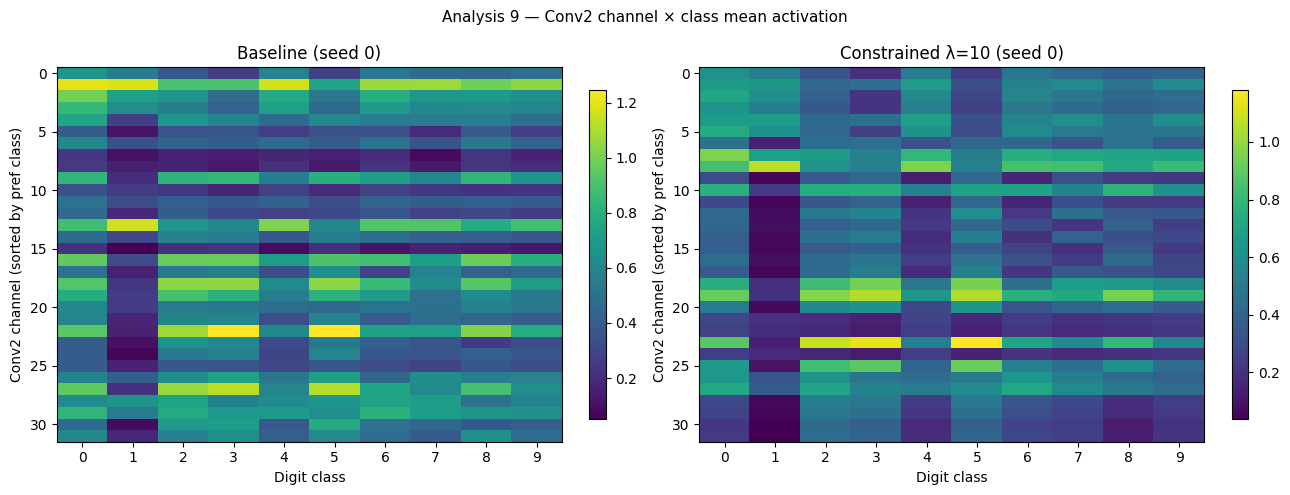

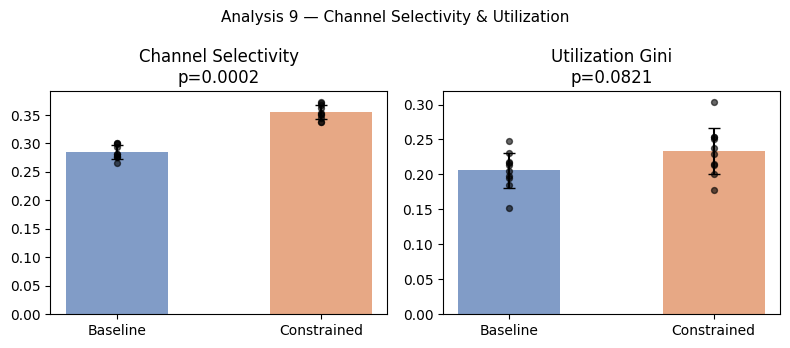

In [41]:
# Visualise per-channel, per-class activation matrix (seed 0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model, ch_pref, title in [
    (axes[0], baseline_models[0],    base_ch_prefs[0],  'Baseline (seed 0)'),
    (axes[1], constrained_models[0], const_ch_prefs[0], 'Constrained λ=10 (seed 0)'),
]:
    ca    = get_conv2_activations(model, test_loader)  # (32, 10)
    order = np.argsort(ch_pref)
    im = ax.imshow(ca[order], cmap='viridis', aspect='auto')
    ax.set_xlabel('Digit class'); ax.set_ylabel('Conv2 channel (sorted by pref class)')
    ax.set_xticks(range(10)); ax.set_xticklabels(range(10))
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.03)
plt.suptitle('Analysis 9 — Conv2 channel × class mean activation', fontsize=11)
plt.tight_layout(); plt.show()

# Bar chart summary
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, bvals, cvals, title in [
    (axes[0], base_sel,  const_sel,  f'Channel Selectivity\np={p9_sel:.4f}'),
    (axes[1], base_gini, const_gini, f'Utilization Gini\np={p9_gini:.4f}'),
]:
    means = [np.mean(bvals), np.mean(cvals)]; stds = [np.std(bvals), np.std(cvals)]
    axes[0 if bvals is base_sel else 1].bar([0,1], means, color=['#4C72B0','#DD8452'],
                                             alpha=0.7, width=0.5)
    ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vl in zip([0,1],[bvals,cvals]):
        ax.scatter([xi]*len(vl), vl, color='k', s=18, zorder=3, alpha=0.6)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Baseline','Constrained'])
    ax.set_title(title)
plt.suptitle('Analysis 9 — Channel Selectivity & Utilization', fontsize=11)
plt.tight_layout(); plt.show()


---
## Analysis 10 — Conv2 Filter Redundancy (Within- vs. Cross-Class Similarity)

Using the same 32×32 cosine similarity matrix from A8: do same-class filters look more alike
than cross-class filters? The difference (within_sim − between_sim) is the "redundancy delta".

Expected: constrained > baseline — clustering pushes the network to develop multiple similar
filters for the same class, creating structural redundancy that mirrors the ablation robustness
seen in A3 (more neurons doing similar things → removing one hurts less).


In [43]:
def filter_redundancy_delta(model, ch_pref):
    """Within-class filter cosine similarity minus between-class similarity."""    
    cos      = conv2_filter_cos_sim(model)                   # (32, 32)
    same_cls = (ch_pref[:, None] == ch_pref[None, :])        # (32, 32)
    np.fill_diagonal(same_cls, False)
    diff_cls = ~same_cls; np.fill_diagonal(diff_cls, False)
    within   = cos[same_cls].mean()  if same_cls.any() else 0.0
    between  = cos[diff_cls].mean()  if diff_cls.any() else 0.0
    return within - between


base_rd  = [filter_redundancy_delta(m, cp)
            for m, cp in zip(baseline_models, base_ch_prefs)]
const_rd = [filter_redundancy_delta(m, cp)
            for m, cp in zip(constrained_models, const_ch_prefs)]

_, p10 = stats.ranksums(const_rd, base_rd)
print(f'A10 — Conv2 filter redundancy delta (within − between class sim):')
print(f'  Baseline    {np.mean(base_rd):.4f} ± {np.std(base_rd):.4f}')
print(f'  Constrained {np.mean(const_rd):.4f} ± {np.std(const_rd):.4f}')
print(f'  Wilcoxon p = {p10:.4f}')


A10 — Conv2 filter redundancy delta (within − between class sim):
  Baseline    0.0867 ± 0.0269
  Constrained 0.2877 ± 0.0569
  Wilcoxon p = 0.0002


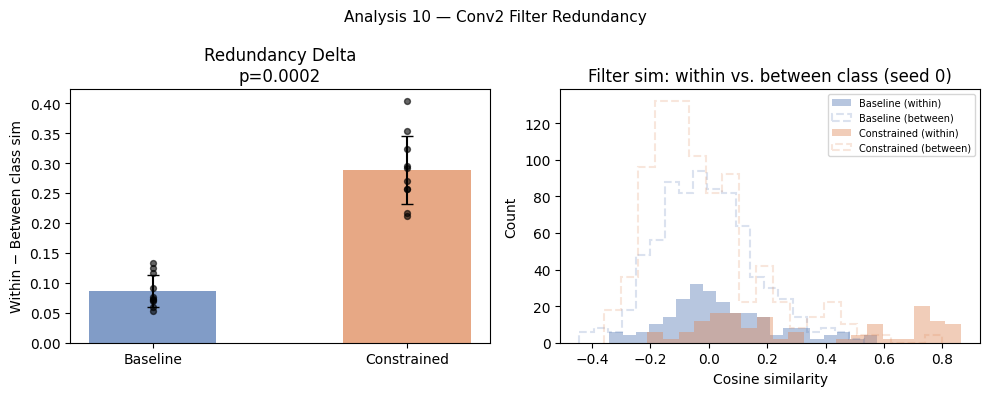

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
ax = axes[0]
means = [np.mean(base_rd), np.mean(const_rd)]
stds  = [np.std(base_rd),  np.std(const_rd)]
ax.bar([0,1], means, color=['#4C72B0','#DD8452'], alpha=0.7, width=0.5)
ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=4)
for xi, vl in zip([0,1],[base_rd, const_rd]):
    ax.scatter([xi]*len(vl), vl, color='k', s=18, zorder=3, alpha=0.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['Baseline','Constrained'])
ax.set_ylabel('Within − Between class sim'); ax.set_title(f'Redundancy Delta\np={p10:.4f}')

# Histogram of within- vs. cross-class similarities for both conditions (seed 0)
ax = axes[1]
for model, ch_pref, label, color in [
    (baseline_models[0],    base_ch_prefs[0],  'Baseline',    '#4C72B0'),
    (constrained_models[0], const_ch_prefs[0], 'Constrained', '#DD8452'),
]:
    cos  = conv2_filter_cos_sim(model)
    same = (ch_pref[:, None] == ch_pref[None, :])
    np.fill_diagonal(same, False)
    diff = ~same; np.fill_diagonal(diff, False)
    ax.hist(cos[same], bins=20, alpha=0.4, color=color, label=f'{label} (within)')
    ax.hist(cos[diff], bins=20, alpha=0.2, color=color, linestyle='--',
            histtype='step', lw=1.5, label=f'{label} (between)')
ax.legend(fontsize=7); ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count'); ax.set_title('Filter sim: within vs. between class (seed 0)')

plt.suptitle('Analysis 10 — Conv2 Filter Redundancy', fontsize=11)
plt.tight_layout(); plt.show()


---
## Updated Summary — All Analyses Including Convolutional Path


Metric                         Baseline   Constrained    p-value   Supported?
------------------------------------------------------------------------------
IAN Homophily (A1)                0.119         0.121     0.3643  ✓ (p=0.364)
Func.Conn. Block (A2)            21.786        81.179     0.0021  ✓ (p=0.002)
Ablation AUAC (A3)                0.660         0.707     0.0015  ✗ (p=0.001)
H2 Attr Entropy (A4)              5.927         5.748     0.0002  ✓ (p=0.000)
H2 Attr Overlap (A4)              0.465         0.405     0.0002  ✓ (p=0.000)
FC Assort. (A6)                   0.076         0.087     0.0082  ✓ (p=0.008)
Conv2 Chan Ent (A7)               3.238         3.089     0.0004  ✓ (p=0.000)
Conv2 Chan Ovlp (A7)              0.899         0.882     0.0821  ✓ (p=0.082)
Conv2 Filt Assort (A8)            0.297         0.512     0.0041  ✓ (p=0.004)
Chan Selectivity (A9)             0.285         0.355     0.0002  ✓ (p=0.000)
Utilization Gini (A9)             0.206         0.233     0.082

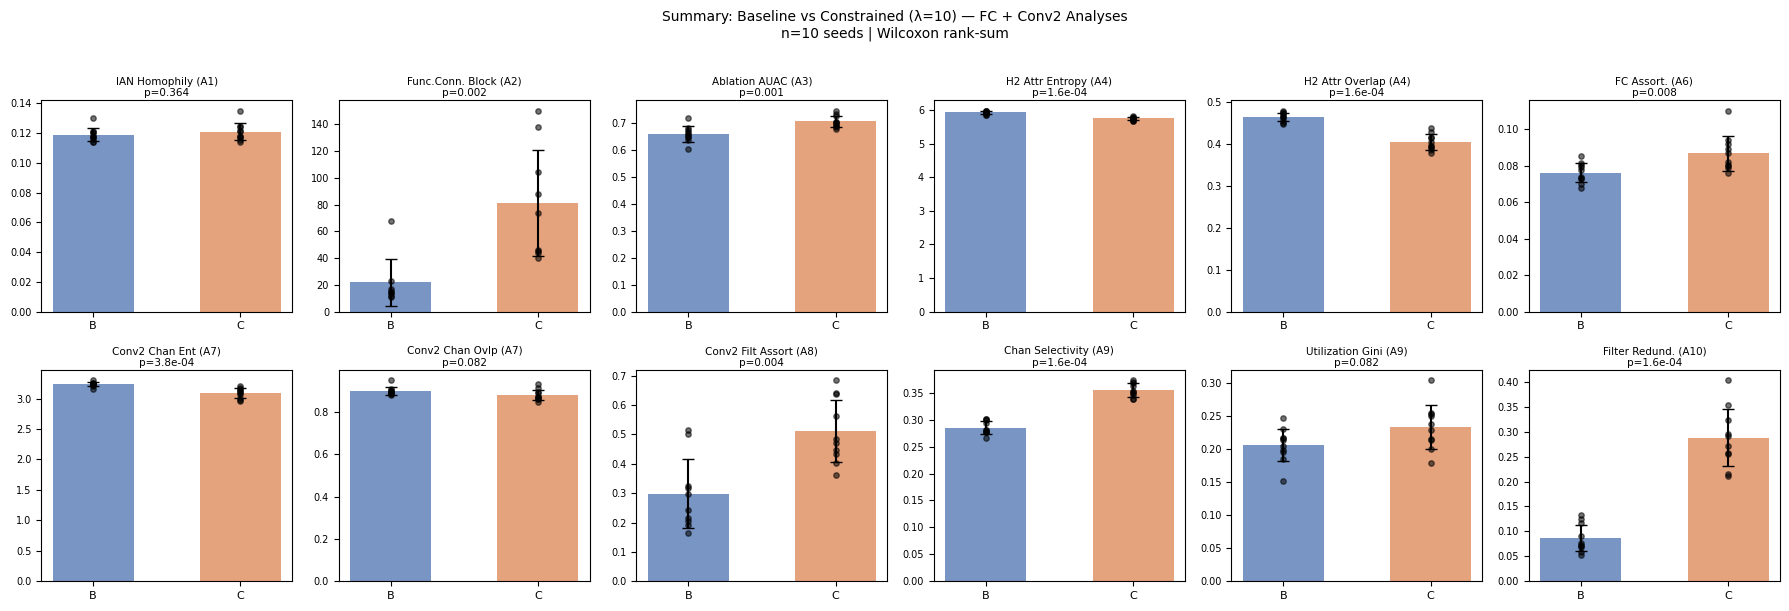

In [45]:
all_metrics = [
    ('IAN Homophily (A1)',        base_tv_scef,  const_tv_scef,  True),
    ('Func.Conn. Block (A2)',     base_block,    const_block,    True),
    ('Ablation AUAC (A3)',        base_auac,     const_auac,     False),
    ('H2 Attr Entropy (A4)',      base_entropy,  const_entropy,  False),
    ('H2 Attr Overlap (A4)',      base_overlap,  const_overlap,  False),
    ('FC Assort. (A6)',           base_assort,   const_assort,   True),
    ('Conv2 Chan Ent (A7)',       base_c_ent,    const_c_ent,    False),
    ('Conv2 Chan Ovlp (A7)',      base_c_over,   const_c_over,   False),
    ('Conv2 Filt Assort (A8)',    base_a8,       const_a8,       True),
    ('Chan Selectivity (A9)',     base_sel,      const_sel,      True),
    ('Utilization Gini (A9)',     base_gini,     const_gini,     True),
    ('Filter Redund. (A10)',      base_rd,       const_rd,       True),
]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

print(f'{"Metric":<28} {"Baseline":>10} {"Constrained":>13} {"p-value":>10} {"Supported?":>12}')
print('-' * 78)

for ax, (name, bvals, cvals, const_higher) in zip(axes, all_metrics):
    bclean = [v for v in bvals if not np.isnan(v)]
    cclean = [v for v in cvals if not np.isnan(v)]
    _, p = stats.ranksums(cclean, bclean)
    bm, cm = np.mean(bclean), np.mean(cclean)
    supported = (const_higher and cm > bm) or (not const_higher and bm > cm)
    print(f'{name:<28} {bm:>10.3f} {cm:>13.3f} {p:>10.4f}  {"✓" if supported else "✗"} (p={p:.3f})')

    means = [bm, cm]; stds = [np.std(bclean), np.std(cclean)]
    ax.bar([0,1], means, color=['#4C72B0','#DD8452'], alpha=0.75, width=0.55)
    ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=4, lw=1.5)
    for xi, vl in zip([0,1],[bclean,cclean]):
        ax.scatter([xi]*len(vl), vl, color='k', s=15, zorder=3, alpha=0.55)
    ax.set_xticks([0,1]); ax.set_xticklabels(['B','C'], fontsize=8)
    p_str = f'{p:.3f}' if p >= 0.001 else f'{p:.1e}'
    ax.set_title(f'{name}\np={p_str}', fontsize=7.5, pad=3)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Summary: Baseline vs Constrained (λ=10) — FC + Conv2 Analyses\nn=10 seeds | Wilcoxon rank-sum',
             fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


---
## Analysis 11 — Computational Path Graph (Revised: Activation × Weight)

A 3-layer wiring diagram (Conv1 → Conv2 → Output class) showing which channels form the
circuit for a target digit. The original weight-only approach failed because taking `abs(W_fc)`
counts *inhibitory* channels as active — in constrained models these are large (cross-class
suppression), making them look *less* sparse. The fix: gate FC weights by actual conv2
activations for the target class (from A9), so only channels that truly fire contribute.

```
FC → Conv2 edge:  importance[ch] = chan_act[ch, c] × |W_fc[c, ch*25:(ch+1)*25]|.mean()
Conv2 → Conv1:    |W_conv2[ch, c1, :, :]|.mean()   (structural, unchanged)
```


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52590/3439181226.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CLASS_CMAP = cm.get_cmap('tab10', 10)


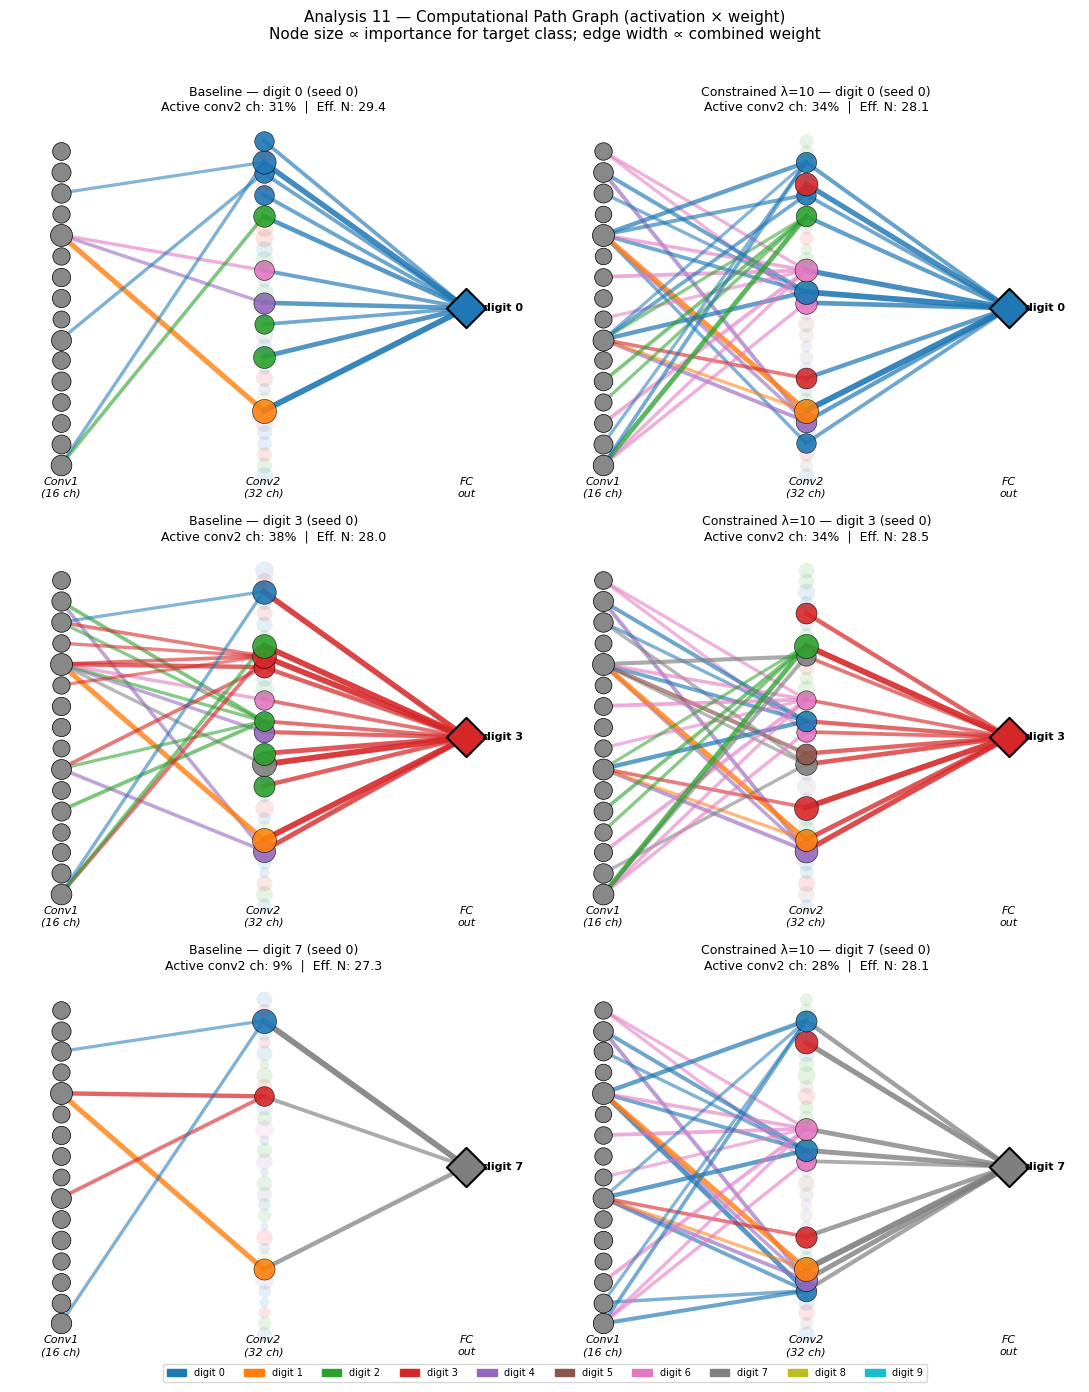

In [53]:
import matplotlib.patches as mpatches
import matplotlib.cm as cm

CLASS_CMAP = cm.get_cmap('tab10', 10)

def get_conv2_act_matrix(model, loader):
    """Return (32, 10) mean conv2 activation per channel per class (after ReLU, before pool)."""    
    model.eval()
    sums = np.zeros((32, 10)); counts = np.zeros(10, dtype=int)
    with torch.no_grad():
        for xb, yb in loader:
            c1  = model.pool(model.relu(model.conv1(xb)))
            c2r = model.relu(model.conv2(c1))               # (B, 32, 11, 11)
            c2m = c2r.mean(dim=(-2, -1)).numpy()             # (B, 32)
            for i, cls in enumerate(yb.numpy()):
                sums[:, cls] += c2m[i]; counts[cls] += 1
    return sums / np.maximum(counts[None, :], 1)             # (32, 10)


def compute_path_weights_v2(model, chan_act, target_class):
    """Activation-gated edge weights for the wiring diagram."""    
    W_fc    = model.fc.weight.detach().numpy()               # (10, 800)
    W_conv2 = model.conv2.weight.detach().numpy()            # (32, 16, 3, 3)

    # FC → Conv2: activation × |mean weight|
    fc_abs_mean = np.array([
        np.abs(W_fc[target_class, ch*25:(ch+1)*25]).mean()
        for ch in range(32)
    ])                                                        # (32,)
    importance = chan_act[:, target_class] * fc_abs_mean     # (32,) — zero if channel silent

    # Conv2 → Conv1: structural weight magnitude
    ch2c1 = np.abs(W_conv2).mean(axis=(-2, -1))             # (32, 16)

    # Composite path back to conv1
    path_c1 = (importance[:, None] * ch2c1).sum(axis=0)     # (16,)
    return importance, ch2c1, path_c1


def draw_path_graph_v2(ax, model, chan_act, ch_pref, target_class,
                       thresh_fc=0.6, thresh_c1=0.6, title=''):
    importance, ch2c1, path_c1 = compute_path_weights_v2(model, chan_act, target_class)

    c1_y  = np.linspace(0.05, 0.95, 16)
    ch_y  = np.linspace(0.02, 0.98, 32)
    out_y = 0.5
    imp_max  = importance.max() + 1e-8
    c1_max   = ch2c1.max()    + 1e-8
    path_max = path_c1.max()  + 1e-8

    # Conv2→Conv1 edges
    for ch in range(32):
        if importance[ch] / imp_max < thresh_fc: continue
        for c1 in range(16):
            w = ch2c1[ch, c1] / c1_max
            if w < thresh_c1: continue
            lw = 0.2 + 3.5 * w; alpha = 0.15 + 0.65 * w
            ax.plot([0, 1], [c1_y[c1], ch_y[ch]],
                    color=CLASS_CMAP(ch_pref[ch]), lw=lw, alpha=alpha, zorder=1)

    # FC→Conv2 edges
    for ch in range(32):
        w = importance[ch] / imp_max
        if w < thresh_fc: continue
        lw = 0.2 + 4.0 * w; alpha = 0.2 + 0.7 * w
        ax.plot([1, 2], [ch_y[ch], out_y],
                color=CLASS_CMAP(target_class), lw=lw, alpha=alpha, zorder=1)

    # Conv2 nodes
    for ch in range(32):
        w = importance[ch] / imp_max
        s = 20 + 280 * w; col = CLASS_CMAP(ch_pref[ch])
        alpha = 0.9 if w >= thresh_fc else 0.12
        ax.scatter([1], [ch_y[ch]], s=s, c=[col], zorder=3,
                   edgecolors='k', linewidths=0.4 if alpha > 0.5 else 0, alpha=alpha)

    # Conv1 nodes
    for c1 in range(16):
        w = path_c1[c1] / path_max; s = 30 + 220 * w
        ax.scatter([0], [c1_y[c1]], s=s, c='#888888', zorder=3,
                   edgecolors='k', linewidths=0.5)

    # Output node
    ax.scatter([2], [out_y], s=400, c=[CLASS_CMAP(target_class)], zorder=3,
               edgecolors='k', linewidths=1.5, marker='D')
    ax.text(2.08, out_y, f'digit {target_class}', va='center', fontsize=8, fontweight='bold')

    # Sparsity stats
    active_frac = (importance / imp_max >= thresh_fc).mean()
    p_norm = importance / (importance.sum() + 1e-8)
    eff_n  = float(np.exp(-np.sum(p_norm * np.log(p_norm + 1e-12))))
    ax.set_xlim(-0.25, 2.35); ax.set_ylim(-0.05, 1.05); ax.axis('off')
    ax.text(0, -0.04, 'Conv1\n(16 ch)', ha='center', fontsize=8, style='italic')
    ax.text(1, -0.04, 'Conv2\n(32 ch)', ha='center', fontsize=8, style='italic')
    ax.text(2, -0.04, 'FC\nout',        ha='center', fontsize=8, style='italic')
    ax.set_title(f'{title}\nActive conv2 ch: {active_frac:.0%}  |  Eff. N: {eff_n:.1f}',
                 fontsize=9, pad=4)


TARGET_CLASSES = [0, 3, 7]
SEED = 0

# Precompute activation matrices for seed 0
base_ca0  = get_conv2_act_matrix(baseline_models[SEED],    test_loader)
const_ca0 = get_conv2_act_matrix(constrained_models[SEED], test_loader)

fig, axes = plt.subplots(len(TARGET_CLASSES), 2,
                          figsize=(11, 4.5 * len(TARGET_CLASSES)))

for row, tgt in enumerate(TARGET_CLASSES):
    for col, (model, chan_act, ch_pref, label) in enumerate([
        (baseline_models[SEED],    base_ca0,  base_ch_prefs[SEED],  'Baseline'),
        (constrained_models[SEED], const_ca0, const_ch_prefs[SEED], 'Constrained λ=10'),
    ]):
        ax = axes[row, col]
        draw_path_graph_v2(ax, model, chan_act, ch_pref, tgt,
                           title=f'{label} — digit {tgt} (seed {SEED})')

handles = [mpatches.Patch(color=CLASS_CMAP(c), label=f'digit {c}') for c in range(10)]
fig.legend(handles=handles, loc='lower center', ncol=10, fontsize=7,
           bbox_to_anchor=(0.5, -0.01))
plt.suptitle('Analysis 11 — Computational Path Graph (activation × weight)\n'
             'Node size ∝ importance for target class; edge width ∝ combined weight',
             fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


Computing sparsity metrics across seeds...
A11 — Active conv2 channel fraction (lower = sparser):
  Baseline    0.912 ± 0.040
  Constrained 0.850 ± 0.077
  Wilcoxon p = 0.0696

A11 — Effective N conv2 channels (lower = more concentrated):
  Baseline    27.19 ± 0.95
  Constrained 25.95 ± 0.88
  Wilcoxon p = 0.0102


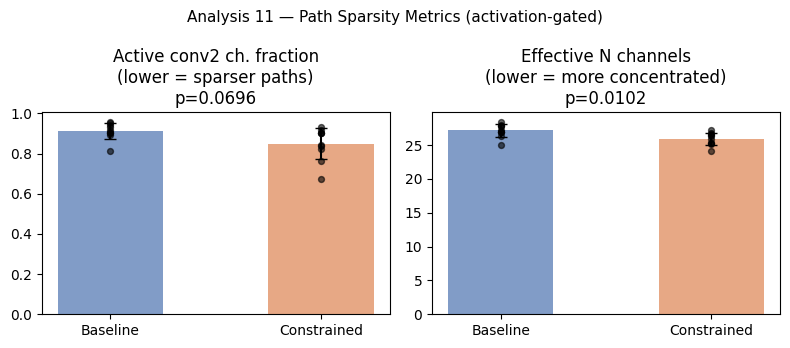

In [49]:
# ── Quantitative: sparsity metrics across all seeds & classes ─────────────────

def path_sparsity_metrics(model, target_class, thresh_fc=0.12):
    ca = get_conv2_act_matrix(model, test_loader)
    importance, _, _ = compute_path_weights_v2(model, ca, target_class)
    imp_max = importance.max() + 1e-8
    active_frac = (importance / imp_max >= thresh_fc).mean()
    p = importance / (importance.sum() + 1e-8)
    eff_n = float(np.exp(-np.sum(p * np.log(p + 1e-12))))
    return active_frac, eff_n

print('Computing sparsity metrics across seeds...')
base_frac,  base_effn  = [], []
const_frac, const_effn = [], []

for m in baseline_models:
    frac, eff = zip(*[path_sparsity_metrics(m, c) for c in range(10)])
    base_frac.append(np.mean(frac)); base_effn.append(np.mean(eff))

for m in constrained_models:
    frac, eff = zip(*[path_sparsity_metrics(m, c) for c in range(10)])
    const_frac.append(np.mean(frac)); const_effn.append(np.mean(eff))

_, p_frac = stats.ranksums(const_frac, base_frac)   # expect const < base
_, p_effn = stats.ranksums(const_effn, base_effn)

print(f'A11 — Active conv2 channel fraction (lower = sparser):')
print(f'  Baseline    {np.mean(base_frac):.3f} ± {np.std(base_frac):.3f}')
print(f'  Constrained {np.mean(const_frac):.3f} ± {np.std(const_frac):.3f}')
print(f'  Wilcoxon p = {p_frac:.4f}')
print()
print(f'A11 — Effective N conv2 channels (lower = more concentrated):')
print(f'  Baseline    {np.mean(base_effn):.2f} ± {np.std(base_effn):.2f}')
print(f'  Constrained {np.mean(const_effn):.2f} ± {np.std(const_effn):.2f}')
print(f'  Wilcoxon p = {p_effn:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, bv, cv, title in [
    (axes[0], base_frac,  const_frac,
     f'Active conv2 ch. fraction\n(lower = sparser paths)\np={p_frac:.4f}'),
    (axes[1], base_effn,  const_effn,
     f'Effective N channels\n(lower = more concentrated)\np={p_effn:.4f}'),
]:
    means = [np.mean(bv), np.mean(cv)]; stds = [np.std(bv), np.std(cv)]
    ax.bar([0,1], means, color=['#4C72B0','#DD8452'], alpha=0.7, width=0.5)
    ax.errorbar([0,1], means, yerr=stds, fmt='none', color='k', capsize=4)
    for xi, vl in zip([0,1],[bv,cv]):
        ax.scatter([xi]*len(vl), vl, color='k', s=18, zorder=3, alpha=0.6)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Baseline','Constrained'])
    ax.set_title(title)
plt.suptitle('Analysis 11 — Path Sparsity Metrics (activation-gated)', fontsize=11)
plt.tight_layout(); plt.show()


---
## Combined Figure — Attribution & Graph Structure (A4, A6, A7, A8)

**Figure caption.** Comparison of baseline (CE-only, blue) and constrained (λ=50, orange) models across six metrics probing how function is organised in the hidden and convolutional layers (*n* = 10 seeds per condition; bars = mean ± s.d.; dots = individual seeds; Wilcoxon rank-sum *p*-values shown above each panel).
*Top row (FC hidden layer):* **A4** — gradient × activation attribution entropy and pairwise overlap across digit classes; **A6** — class assortativity of the FC weight-similarity graph.
*Bottom row (Conv2 layer):* **A7** — per-class channel attribution entropy and overlap; **A8** — class assortativity of the conv2 filter cosine-similarity graph.
Constrained models show lower attribution entropy and overlap (less distributed, more class-selective circuits) and higher assortativity (neurons/filters with similar output profiles preferentially connect within the same class).


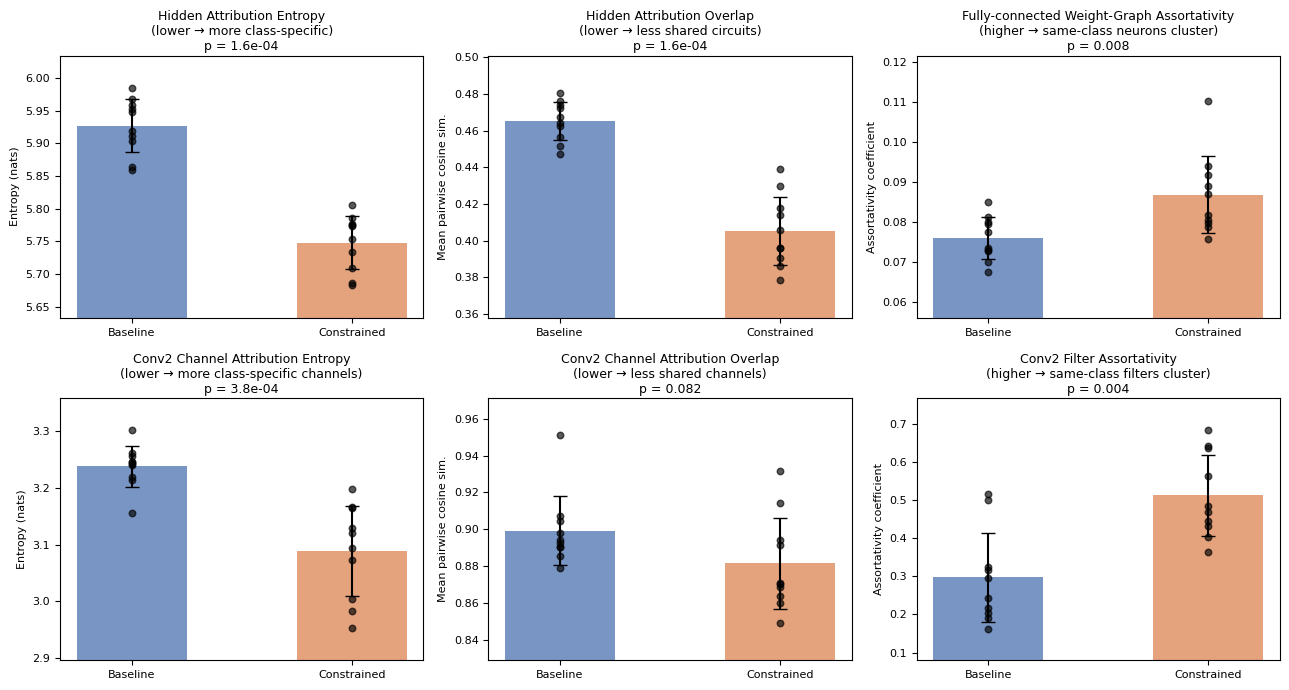

In [57]:
def _bar_panel(ax, bvals, cvals, title, p_val, zoom_pad=0.15):
    """Reusable bar+scatter panel with auto-zoomed y-limits."""
    bclean = [v for v in bvals if not np.isnan(v)]
    cclean = [v for v in cvals if not np.isnan(v)]
    means = [np.mean(bclean), np.mean(cclean)]
    stds  = [np.std(bclean),  np.std(cclean)]

    ax.bar([0, 1], means, color=['#4C72B0', '#DD8452'], alpha=0.75, width=0.5)
    ax.errorbar([0, 1], means, yerr=stds, fmt='none', color='k', capsize=5, lw=1.5)
    for xi, vl in zip([0, 1], [bclean, cclean]):
        ax.scatter([xi] * len(vl), vl, color='k', s=22, zorder=4, alpha=0.65)

    all_vals = bclean + cclean
    lo = min(all_vals) - zoom_pad * (max(all_vals) - min(all_vals) + 1e-8)
    hi = max(all_vals) + zoom_pad * (max(all_vals) - min(all_vals) + 1e-8)
    # ensure error bars fit
    lo = min(lo, min(means[i] - stds[i] for i in range(2))) - 0.005
    hi = max(hi, max(means[i] + stds[i] for i in range(2))) + 0.005
    ax.set_ylim(lo, hi)

    p_str = f'{p_val:.3f}' if p_val >= 0.001 else f'{p_val:.1e}'
    ax.set_title(f'{title}\np = {p_str}', fontsize=9, pad=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Baseline', 'Constrained'], fontsize=8)
    ax.tick_params(axis='y', labelsize=8)


fig, axes = plt.subplots(2, 3, figsize=(13, 7))

# ── Row 1: FC hidden layer (A4, A4, A6) ────────────────────────────────────
_bar_panel(axes[0, 0], base_entropy,  const_entropy,
           'Hidden Attribution Entropy\n(lower → more class-specific)', p_ent)
axes[0, 0].set_ylabel('Entropy (nats)', fontsize=8)

_bar_panel(axes[0, 1], base_overlap,  const_overlap,
           'Hidden Attribution Overlap\n(lower → less shared circuits)', p_over)
axes[0, 1].set_ylabel('Mean pairwise cosine sim.', fontsize=8)

_bar_panel(axes[0, 2], base_assort,   const_assort,
           'Fully-connected Weight-Graph Assortativity\n(higher → same-class neurons cluster)', p6)
axes[0, 2].set_ylabel('Assortativity coefficient', fontsize=8)

# ── Row 2: Conv2 layer (A7, A7, A8) ────────────────────────────────────────
_bar_panel(axes[1, 0], base_c_ent,   const_c_ent,
           'Conv2 Channel Attribution Entropy\n(lower → more class-specific channels)', p_c_ent)
axes[1, 0].set_ylabel('Entropy (nats)', fontsize=8)

_bar_panel(axes[1, 1], base_c_over,  const_c_over,
           'Conv2 Channel Attribution Overlap\n(lower → less shared channels)', p_c_over)
axes[1, 1].set_ylabel('Mean pairwise cosine sim.', fontsize=8)

_bar_panel(axes[1, 2], base_a8,      const_a8,
           'Conv2 Filter Assortativity\n(higher → same-class filters cluster)', p8)
axes[1, 2].set_ylabel('Assortativity coefficient', fontsize=8)

#plt.suptitle(
#    'Attribution & Graph Structure: Baseline vs. Constrained (λ=50)\n'
#    'n = 10 seeds per condition  |  bars: mean ± s.d.  |  dots: individual seeds',
#    fontsize=11, y=1.01
#)
plt.tight_layout()
plt.savefig('../fig/paper/attribution_graph_structure.pdf', dpi=300)
plt.show()
